In [15]:
from openai import OpenAI

# Initialize the client with the API key
client = OpenAI(api_key="insert your key here")

# Retrieve the list of models
models_response = client.models.list()

# Print each model's details line by line
for model in models_response.data:
    print(f"Model ID: {model.id}")
    print(f"Created: {model.created}")
    print(f"Object: {model.object}")
    print(f"Owned by: {model.owned_by}")
    print("-" * 40)


Model ID: gpt-4-0613
Created: 1686588896
Object: model
Owned by: openai
----------------------------------------
Model ID: gpt-4
Created: 1687882411
Object: model
Owned by: openai
----------------------------------------
Model ID: gpt-3.5-turbo
Created: 1677610602
Object: model
Owned by: openai
----------------------------------------
Model ID: chatgpt-image-latest
Created: 1765925279
Object: model
Owned by: system
----------------------------------------
Model ID: gpt-4o-mini-tts-2025-03-20
Created: 1765610731
Object: model
Owned by: system
----------------------------------------
Model ID: gpt-4o-mini-tts-2025-12-15
Created: 1765610837
Object: model
Owned by: system
----------------------------------------
Model ID: gpt-realtime-mini-2025-12-15
Created: 1765612007
Object: model
Owned by: system
----------------------------------------
Model ID: gpt-audio-mini-2025-12-15
Created: 1765760008
Object: model
Owned by: system
----------------------------------------
Model ID: davinci-002
C

In [17]:
import pandas as pd
df = pd.read_excel("Phase1.xlsx")
df


,title,publication_year,abstract,journal_name,publisher,author,author_affiliation,keywords
0,Comparison Of Family Therapy Outcome With Alco...,2009.0,"Treatment evaluation for alcohol problem, runa...",Journal of marital and family therapy,NIH Public Access,"Natasha Slesnick, Jillian Prestopnik","Ohio State University, The University of New M...","adolescents, runaways, family therapy, alcohol..."
1,Intervention With Substance-Abusing Runaway Ad...,2013.0,Objectives\nTo examine the efficacy of three t...,Journal of consulting and clinical psychology,"Washington, DC: American Psychological Associa...","Natasha Slesnick, Gizem Erdem, Suzanne Bartle-...",Department of Human Sciences at the Ohio State...,"runaway adolescents, substance abuse treatment..."
2,Implementing A Psychologically Informed Enviro...,2014.0,Purpose\n- The purpose of this paper is to des...,"Housing, Care and Support",Brighton: Emerald Group Publishing Limited,"Jeremy Woodcock, Jamie Gill",Dr Jeremy Woodcock is a Consultant Psychothera...,"Homeless, Young people, Learning organization,..."
3,Evaluation Of Harsh Reality: A Sexual Health P...,2013.0,Introduction: Street-involved youth are one of...,Health Education Journal,"London, England: SAGE Publications","Chelsea Jalloh, Barbara McMillan, Margaret Orm...",Department of Curriculum Teaching and Learning...,"Street-involved youth, sexually transmitted in..."
4,"Necessary, But Not Sufficient: The Mckinney-Ve...",2012.0,The McKinney–Vento Homeless Education Assistan...,Children & Schools,Oxford: Oxford University Press,"George Hendricks, William Barkley",School of Social Work at Methodist University ...,academic achievement; end-of-grade test scores...
...,...,...,...,...,...,...,...,...
455,The Student Homelessness Crisis And The Role O...,2016.0,"Affecting more than 1 million youth, student h...",Psychology in the Schools,NaN,Michael L. Sulkowski,University of Arizona,NaN
456,Perceptions Of Resiliency And Coping: Homeless...,2013.0,This study explored the perceptions of resilie...,Youth & Society,NaN,"Sanna J. Thompson SannaThompson@utexas.edu, Ti...","School of Social Work, University of Texas at ...",NaN
457,Home(Lessness) In Urbanizing China: Invisible ...,2016.0,This article examines how martial arts student...,Education and Urban Society,NaN,Xuan Dong,"East China Normal University, Shanghai, China",NaN
458,"Performing To Understand: Cultural Wealth, Pre...",2017.0,"Collaborating withProject: Humanity, an acclai...",Research in Drama Education,NaN,"Kathleen Gallagher, Dirk J. Rodricks","Ontario Institute for Studies in Education, Un...","applied theatre methodology, critical race the..."


In [21]:
#Prompt 1 

from openai import OpenAI
import pandas as pd
import json
import time

# Initialize the OpenAI client 
client = OpenAI(api_key="Insert your key here")


def get_decision_for_row(row, row_index):
    study_details = (
        f"Title: {row['title']}\n"
        f"Abstract: {row['abstract']}\n"
        f"Publication Year: {row['publication_year']}\n"
        f"Journal Name: {row['journal_name']}\n"
        f"Author: {row['author']}\n"
        f"Author Affiliation: {row['author_affiliation']}\n"
        f"Keywords: {row['keywords']}"
    )
    
    prompt = f"""
    You are an expert reviewer for research studies with human-like reasoning. Your goal is to identify empirical studies about youth homelessness interventions that should be considered for inclusion. Based on the study details below, the tnterpretation guidance, and the eligibility criteria, decide if the study should be included. Use contextual inference to reduce false negatives (e.g., lean toward 'Yes' when ambiguous but not definitively 'No'). 

    Study Details: {study_details}

    Interpretation Guidance:
    - If a study uses terms like "youth," "adolescents," or "young people," assume the target age is 13–25 unless contradicted.
    - Use 'Publication Year' from the study details as the definitive publication date, ignoring earlier years mentioned in the abstract (e.g., data collection years).
    - If a country isn’t mentioned, assume OECD unless evidence suggests otherwise.
    - If a program/intervention is described with outcomes (e.g., reduced substance use, test scores), assume effectiveness is reported.
    - If the study discusses how the intervention was applied, implemented, or delivered, assume it reports on implementation. To further explain, if the study describes assignment to interventions, group comparisons (e.g., treatment vs. control), or engagement/process details, assume implementation is reported.
    - When eligibility is unclear but aligns with the review’s goal (youth homelessness interventions), lean toward inclusion.


    Eligibility Criteria:
    1. Original or Empirical Research: The study is based on observation and measurement of phenomena using primary data. Secondary data may form the theoretical background. Editorials, letters, and protocols are not included.
    2. Publication Date: Published in 2008 or later.
    3. Target Population (Age): Focuses on youth aged 13–25 (infer from relevant words such as "youth," "adolescents," "young people", etc.).
    4. Target Population (Homelessness): Focuses on youth who are homeless, unstably housed, or at risk of homelessness, including those who: a) are unstably housed, b) have run away from home, c) are currently homeless, or d) are at risk of homelessness (infer from related terms like 'runaway' or 'housing instability').
    5. Geographical Scope: Conducted in an OECD country. OECD countries are: Australia, Austria, Belgium, Canada, Chile, Colombia, Czech Republic, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Iceland, Ireland, Israel, Italy, Japan, Korea, Latvia, Lithuania, Luxembourg, Mexico, Netherlands, New Zealand, Norway, Poland, Portugal, Slovak Republic, Slovenia, Spain, Sweden, Switzerland, Turkey, United Kingdom, United States (infer from country names, author affiliation, or journal if not explicit. If  If a country is not mentioned, assume it is in the OECD.).
    6. Study Focus: Describes a program, service, or intervention related to youth homelessness (infer from context if not explicit).
    7. Effectiveness Reporting: Reports effectiveness of the program, service, or intervention (infer from outcomes or results if 'effectiveness' isn’t explicit).
    8. Implementation Reporting: Reports implementation of the program, service, or intervention (infer from process descriptions, such as assignment, group design, or process details, if 'implementation' isn’t explicit).

    Exclusion Codes:
    - X-0: Not original/empirical research
    - X-1: Published before 2018
    - X-2: Target population not youth (outside 13–25)
    - X-3: Population not homeless/at risk
    - X-4: Not in an OECD country
    - X-5: No program/service/intervention
    - X-6a: No effectiveness reported
    - X-6b: No implementation reported

    Instructions:
    - Evaluate each criterion holistically, inferring where reasonable (e.g., 'youth' = 13–25).
    - Prioritize 'Publication Year' from study details for criterion 2.
    - Lean toward 'Yes' when a criterion is ambiguous but not definitively unmet, especially for criteria 7 and 8, to reduce false negatives.
    - Return:
      1. "Criteria_Results": List of 8 answers ("Yes" or "No (X-code)")
      2. "Decision": "Yes" if all criteria are "Yes", "No" if any are "No"
      3. "Explanation": "N/A" for Yes, list of codes for No
    - Return only the JSON object.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are an expert reviewer with human-like reasoning."},
                {"role": "user", "content": prompt}
            ],
            temperature=0  # Could be slightly higher for flexibility while maintaining consistency
        )
        reply = response.choices[0].message.content.strip()
        # Clean markdown-style backticks
        if reply.startswith("```json"):
            reply = reply.replace("```json", "").strip("` \n")
        elif reply.startswith("```"):
            reply = reply.strip("` \n")
        
        try:
            result = json.loads(reply)
            return (
                result.get("Decision", "No"),  # Default to "No" if parsing fails
                result.get("Explanation", "Parse error"),
                result.get("Criteria_Results", [])
            )
        except json.JSONDecodeError:
            print(f"⚠️ JSON parse error on row {row_index + 1}")
            print("GPT Reply:\n", reply)
            return "No", "Parse error", []
    except Exception as e:
        print(f"❌ Error on row {row_index + 1}: {e}")
        return "No", "API error", []

# Process all rows
decisions = []
explanations = []
criteria_logs = []
for i, row in df.iterrows():
    decision, explanation, criteria = get_decision_for_row(row, i)
    decisions.append(decision)
    explanations.append(explanation)
    criteria_logs.append(str(criteria))
    time.sleep(1)  # Respect API rate limits

# Add results to DataFrame
df["Decision"] = decisions
df["Explanation"] = explanations
df["Criteria_Results"] = criteria_logs

# Save the results
output_path = "Phase1_with_FNreduction_temp0.xlsx"
df.to_excel(output_path, index=False)
print(f"\n✅ Processing complete. File saved to: {output_path}")



✅ Processing complete. File saved to: Phase1_with_FNreduction_temp0.xlsx


In [23]:
temp0 = pd.read_excel("Phase1_with_FNreduction_temp0.xlsx")


In [25]:
temp0['Decision'].value_counts()

Decision
No     413
Yes     47
Name: count, dtype: int64

In [27]:
human = pd.read_excel("Phase1_with_humans_updated.xlsx")

In [29]:
human['is.included'].value_counts()

is.included
0    367
1     93
Name: count, dtype: int64

In [31]:
import pandas as pd

# Load the two datasets
df1 = temp0
df2 = human

# Define the shared columns to merge on
shared_columns = [
    "title", 
    "publication_year", 
    "abstract", 
    "journal_name", 
    "author", 
    "author_affiliation", 
    "keywords"
]

# Perform the merge
merged_df = pd.merge(df1, df2, on=shared_columns, how="outer", suffixes=("_GPT", "_Human"))

# Save to a new Excel file
merged_df.to_excel("Phase1_merged.xlsx", index=False)

print("✅ Merging complete. Output saved to Phase1_merged.xlsx")


✅ Merging complete. Output saved to Phase1_merged.xlsx


In [33]:
merged_df = pd.read_excel("Phase1_merged.xlsx")

In [35]:
merged_df.shape

(462, 19)

In [37]:
merged_df

,title,publication_year,abstract,journal_name,publisher_GPT,author,author_affiliation,keywords,Decision,Explanation,Criteria_Results,publisher_Human,notes,is.included,inclusion_label1,inclusion_label2,exclusion_label1,exclusion_label2,exclusion_label3
0,"""Bad Things Could Happen"": How Fear Impedes So...",2008.0,"In this study, I compared the shifts in attitu...",Journal of adolescent research,NaN,Scott Seider,Boston University,"social responsibility, emerging adulthood, pri...",No,"X-1, X-3, X-5, X-6a, X-6b","['Yes', 'No (X-1)', 'Yes', 'No (X-3)', 'Yes', ...",NaN,"<p>RAYYAN-INCLUSION: {""Shannon""=>false, ""Alexa...",0,NaN,NaN,"The study does not describe a program, service...",NaN,NaN
1,"""Children Of The Street"": Sexual Citizenship A...",2012.0,Youth-sensitive policies are gradually gaining...,Comparative Education,NaN,Georgina Yaa Oduro,"University of Cape Coast, Ghana",NaN,No,"X-4, X-5, X-6a, X-6b","['Yes', 'Yes', 'Yes', 'Yes', 'No (X-4)', 'No (...",NaN,"<p>RAYYAN-INCLUSION: {""Shannon""=>false, ""Alexa...",0,NaN,NaN,The study was not conducted in an OECD country,NaN,NaN
2,"""Housing First"" For Homeless Youth With Mental...",2016.0,"""Housing First"" has been shown to improve hous...",Pediatrics (Evanston),United States: American Academy of Pediatrics,Nicole Kozloff; Carol E. Adair; Luis I. Palma ...,"Centre for Urban Health Solutions, Li Ka Shing...","homeless youth, housing, mental disorders, sta...",Yes,NaN,"['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'Ye...",United States: American Academy of Pediatrics,"RAYYAN-INCLUSION: {""Shannon""=>true, ""Reiko""=>t...",1,NaN,NaN,NaN,NaN,NaN
3,"""I Don't Want To Live Like This Anymore"": Disr...",2013.0,This article reports on interview data gathere...,Youth & Society,NaN,"Tony Gilbert, Paul Farrand, Gloria Lankshear","School of Social Science and Social Work, Facu...","Bourdieu, crisis, personality disorder, self-h...",No,"X-3, X-5, X-6a, X-6b","['Yes', 'Yes', 'Yes', 'No (X-3)', 'Yes', 'No (...",NaN,"<p>RAYYAN-INCLUSION: {""Shannon""=>false, ""Alexa...",0,NaN,NaN,The target population is not homeless or unsta...,NaN,NaN
4,"""It's Good To Have Wheels!"" Perceptions Of Cyc...",2012.0,Participation in sporting or recreational prog...,Youth Studies Australia,NaN,"Belinda Crawford, Christopher Rissel, Rowena Y...",University of New South Wales; University of S...,"cycling, among, homeless, young, people, sydne...",No,"X-5, X-6a, X-6b","['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No (X-5)'...",NaN,"<p>RAYYAN-INCLUSION: {""Shannon""=>false, ""Alexa...",0,NaN,NaN,"The study does not describe a program, service...",NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
457,Youth Perspectives On Sexual Health Workshops:...,2015.0,Newcomer and street-involved youth provided th...,Qualitative health research,NaN,"Heather Ashdown, Chelsea Jalloh, John L. Wylie","University of Manitoba, Winnipeg, Manitoba, Ca...",adolescents / youth; at-risk; focus groups; he...,No,"X-3, X-5, X-6a, X-6b","['Yes', 'Yes', 'Yes', 'No (X-3)', 'Yes', 'No (...",NaN,"RAYYAN-INCLUSION: {""Shannon""=>true, ""Reiko""=>t...",1,Background,Need more information,"The study does not describe a program, service...",NaN,NaN
458,"Youth, Musical Education And Media: Singularit...",2011.0,The place of popular and multifunctional media...,"Action, criticism, & theory for music education",NaN,Jusamara Souza,"Federal University of Rio Grande do Sul, Brazil",NaN,No,"X-0, X-3, X-5, X-6a, X-6b","['No (X-0)', 'Yes', 'Yes', 'No (X-3)', 'Yes', ...",NaN,"<p>RAYYAN-INCLUSION: {""Shannon""=>false, ""Alexa...",0,NaN,NaN,The target population is not homeless or unsta...,NaN,NaN
459,Youth-Adult Connectedness:: A Key Protective F...,2017.0,"Over the past 30 years, prevention science in ...",American journal of preventive medicine,Netherlands: Elsevier Science Ltd,"Renee E. Sieving, Annie-Laurie McRee, Barbara ...",Healthy Youth Development–Prevention Research ...,NaN,No,"X-1, X-6b","['Yes', 'No (X-1)', 'Yes', 'Yes', 

In [39]:
merged_df['Decision_binary'] = merged_df['Decision'].replace({
    'No': 0,
    'Yes': 1,
})


/var/folders/6l/_j3ymxdx3bndlj9z22_9d6000000gp/T/ipykernel_99840/654654470.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  merged_df['Decision_binary'] = merged_df['Decision'].replace({


In [41]:
merged_df['Decision_binary'].value_counts()

Decision_binary
0    415
1     47
Name: count, dtype: int64

In [43]:
merged_df['is.included'].value_counts()

is.included
0    369
1     93
Name: count, dtype: int64

True Positives (TP): 40
True Negatives (TN): 362
False Positives (FP): 7
False Negatives (FN): 53
Precision: 0.8511
Recall: 0.4301
F1 Score: 0.5714
AUC: 0.7056


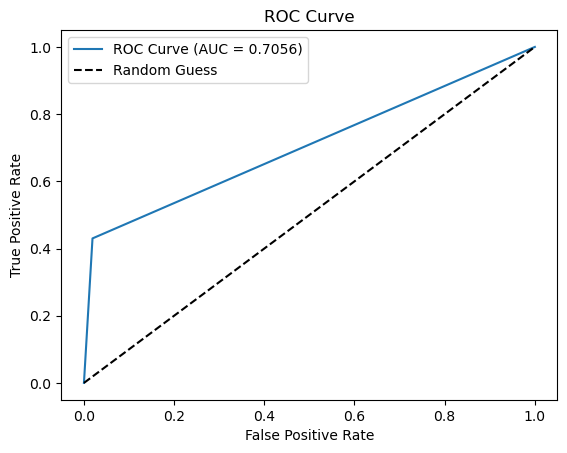

In [45]:
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt


# Extract observed and predicted values
y_true = merged_df["is.included"]
y_pred = merged_df["Decision_binary"]

# Calculate confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Calculate precision, recall, and F1
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Calculate AUC (using binary predictions)
auc = roc_auc_score(y_true, y_pred)

# Print results
print(f"True Positives (TP): {tp}")
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC: {auc:.4f}")

# Optional: Plot ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred)
plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="best")
plt.show()

In [142]:
#Prompt 2
from openai import OpenAI
import pandas as pd
import json
import time



def get_decision_for_row(row, row_index):
    study_details = (
        f"Title: {row['title']}\n"
        f"Abstract: {row['abstract']}\n"
        f"Publication Year: {row['publication_year']}\n"
        f"Journal Name: {row['journal_name']}\n"
        f"Author: {row['author']}\n"
        f"Author Affiliation: {row['author_affiliation']}\n"
        f"Keywords: {row['keywords']}"
    )

    prompt = f"""
You are an expert reviewer for research studies with human-like reasoning. Your goal is to assist in pre-screening abstracts to identify studies that might meet inclusion criteria for a systematic review of youth homelessness interventions. This is an initial triage, not a final eligibility decision.

When abstracts are ambiguous or incomplete, lean toward inclusion for further review to minimize false negatives.

---

Study Details:
{study_details}

---

Pre-Screening Focus:
1. Original/Empirical Research — Study is based on primary data or direct observations. Exclude editorials, letters, protocols, systematic reviews, meta-analyses, and studies that rely only on secondary data or reanalysis of existing datasets.
2. Target Population (Age) — Youth aged 13–25. If the study uses terms like "youth," "adolescents," "young people," or any related terms, infer target age as 13–25 unless clearly contradicted. If no age is mentioned but the population is described as youth-related, include. If the study does not mention age, lean toward inclusion.
3. Target Population (Homelessness) — Youth who are homeless, unstably housed, or at risk of homelessness. Include if related terms appear (e.g., "runaway," "refugee minor," "vulnerably housed," "shelter youth," or other at-risk housing terms). If the population is described as disadvantaged or vulnerable and housing status is unclear, lean toward inclusion.
4. Program/Service/Intervention Focus — Includes any program, service, or intervention delivered to youth who are homeless, unstably housed, or at risk of homelessness, regardless of whether the intervention directly targets housing or homelessness. For example, interventions addressing substance use, risky sexual behavior, mental health, or trauma among homeless or at-risk youth are relevant.

Other criteria (effectiveness reporting, implementation reporting, full geographical confirmation) will be checked at full-text review. Do not exclude based on these at this stage.

---

Decision Instructions:
- Recommend Include when study details match or might match the pre-screening focus areas.
- Recommend Exclude only if there is clear evidence that the study does not match focus areas.
- When in doubt, lean toward Include to minimize false negatives.

Return a list of codes indicating which criteria were not met (for Exclude):
- X-1: Not original/empirical research (e.g., editorials, letters, protocols, reviews, meta-analyses, secondary data studies)
- X-2: Target population obvioursly not youth (i.e., specifically mention the age range outside 13–25)
- X-3: Specifically mention that population not homeless/at risk 
- X-4: No program/service/intervention focus

---

Return a JSON object in the following format:
{{
  "Decision": "Include" | "Exclude",
  "Explanation_Codes": ["X-code", ...] or [],
  "Focus_Area_Results": {{
    "Original_Empirical": "Yes" | "No",
    "Youth_Age_13_25": "Yes" | "No",
    "Homelessness_Target": "Yes" | "No",
    "Program_Focus": "Yes" | "No"
  }}
}}

Examples:
- A study on a youth housing program with no specified outcomes: Decision = Include, Explanation_Codes = []
- A review article with no primary data: Decision = Exclude, Explanation_Codes = ["X-1"]
- A mentoring program for disadvantaged youth without clear housing details: Decision = Include, Explanation_Codes = []
- A substance use intervention for homeless youth — Decision = Include, Explanation_Codes = []
- A trauma intervention for unaccompanied refugee minors — Decision = Include, Explanation_Codes = []
- A supportive housing program study where the age of participants are not mentioned — Decision = Include, Explanation_Codes = []

---

Return only the JSON object, no extra text.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are an expert reviewer with human-like reasoning."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        reply = response.choices[0].message.content.strip()

        # Clean markdown-style formatting if present
        if reply.startswith("```json"):
            reply = reply.replace("```json", "").strip("` \n")
        elif reply.startswith("```"):
            reply = reply.strip("` \n")

        # Parse JSON
        result = json.loads(reply)
        return (
            result.get("Decision", "Exclude"),
            json.dumps(result.get("Explanation_Codes", [])),
            json.dumps(result.get("Focus_Area_Results", {}))
        )

    except json.JSONDecodeError:
        print(f"⚠️ JSON parse error on row {row_index + 1}")
        print("GPT Reply:\n", reply)
        return "Exclude", json.dumps(["Parse error"]), json.dumps({})
    except Exception as e:
        print(f"❌ Error on row {row_index + 1}: {e}")
        return "Exclude", json.dumps(["API error"]), json.dumps({})

# Run the review across all rows
decisions = []
explanation_codes = []
focus_area_logs = []

for i, row in df.iterrows():
    decision, explanation, focus_areas = get_decision_for_row(row, i)
    decisions.append(decision)
    explanation_codes.append(explanation)
    focus_area_logs.append(focus_areas)
    time.sleep(1)  # Respect API rate limit

# Save output
df["Decision"] = decisions
df["Explanation_Codes"] = explanation_codes
df["Focus_Area_Results"] = focus_area_logs

output_path = "Phase1_strategy_2.1_refined.xlsx"
df.to_excel(output_path, index=False)
print(f"\n✅ Processing complete. File saved to: {output_path}")



✅ Processing complete. File saved to: Phase1_strategy_2.1_refined.xlsx


In [144]:
AI = pd.read_excel("Phase1_strategy_2.1_refined.xlsx")

In [146]:
AI['Decision'].value_counts()

Decision
Exclude    255
Include    205
Name: count, dtype: int64

In [160]:
import pandas as pd

# Load data
AI = pd.read_excel("Phase1_strategy_2.1_refined.xlsx")
human = pd.read_excel("Phase1_with_humans_updated.xlsx")

# Merge by index (or adjust if you have an ID column)
combined = pd.concat([AI, human], axis=1)

# Drop duplicate columns (if any columns are fully redundant / duplicated across datasets)
# Create a set of columns to keep: drop any duplicates based on column name and identical content
# We'll detect duplicated columns by value
def drop_redundant_columns(df):
    cols_to_drop = []
    for i, col1 in enumerate(df.columns):
        for col2 in df.columns[i + 1:]:
            if col1 != col2 and df[col1].equals(df[col2]):
                cols_to_drop.append(col2)
    return df.drop(columns=set(cols_to_drop))

combined = drop_redundant_columns(combined)

# Create alignment column
def classify_alignment(row):
    ai_decision = row["Decision"]
    human_included = row["is.included"]
    
    if ai_decision == "Include" and human_included == 1:
        return "Aligned: Both Include"
    elif ai_decision == "Exclude" and human_included == 0:
        return "Aligned: Both Exclude"
    elif ai_decision == "Include" and human_included == 0:
        return "AI Include, Human Exclude"
    elif ai_decision == "Exclude" and human_included == 1:
        return "AI Exclude, Human Include"
    else:
        return "Other"

combined["Alignment"] = combined.apply(classify_alignment, axis=1)

# Show counts
alignment_counts = combined["Alignment"].value_counts()
print(alignment_counts)

# Save to file
combined.to_excel("Phase1_alignment_check_no_maybe_clean.xlsx", index=False)
print("\n✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx")


Alignment
Aligned: Both Exclude        225
AI Include, Human Exclude    122
Aligned: Both Include         83
AI Exclude, Human Include     30
Name: count, dtype: int64

✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx


In [162]:
# Calculate confusion matrix components
TP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 1)].shape[0]
FP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 0)].shape[0]
TN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 0)].shape[0]
FN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 1)].shape[0]

# Calculate metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0  # Sensitivity
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Print results
print("\nConfusion Matrix Counts:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")

print("\nAI Effectiveness Metrics for Systematic Review Pre-screening:")
print(f"Precision (Positive Predictive Value): {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")



Confusion Matrix Counts:
True Positives (TP): 83
False Positives (FP): 122
True Negatives (TN): 225
False Negatives (FN): 30

AI Effectiveness Metrics for Systematic Review Pre-screening:
Precision (Positive Predictive Value): 0.405
Recall (Sensitivity): 0.735
Specificity: 0.648
Accuracy: 0.670
F1 Score: 0.522


In [164]:
# Filter for AI Exclude, Human Include
mismatched = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 1)]

# Display key columns (e.g., title + abstract + explanation codes if present)
columns_to_show = [col for col in combined.columns if "title" in col.lower() or "abstract" in col.lower()] + ["Decision", "is.included", "Explanation_Codes"]

print("\nAI Exclude, Human Include cases:")
print(mismatched[columns_to_show])

# Optionally save to file for review
mismatched.to_excel("Phase1_AI_exclude_human_include_mismatches.xlsx", index=False)
print("\n✅ Mismatched studies saved as Phase1_AI_exclude_human_include_mismatches.xlsx")



AI Exclude, Human Include cases:
                                                 title  \
4    Necessary, But Not Sufficient: The Mckinney-Ve...   
11   Health Status, Quality Of Life, Residential St...   
18   Interventions To Modify Sexual Risk Behaviours...   
22   Editorial Perspective: Effective Mental Health...   
24   Can Housing And Service Interventions Reduce F...   
39   Causes Of Child And Youth Homelessness In Deve...   
43   Trajectories Of Women's Homelessness In Canada...   
58   Exiting Homelessness: Perceived Changes, Barri...   
61   Housing First Is Associated With Reduced Use O...   
64   Community-Based Hcv Screening: Knowledge And A...   
68   Asthma, Tobacco Smoke And The Indoor Environme...   
77   Developing Dental Services For Homeless People...   
83   Addressing Smoking And Other Health Risk Behav...   
90   Unique Health Care Utilization Patterns In A H...   
94   Substance Use Outcomes Among Homeless Clients ...   
96   A Fortified Street Food To Preven

In [166]:
# Prompt 3-few shots-direct decision-binary
#According to those 30 studies, many of your should-have-included examples share traits:

#Mixed age groups where youth are likely present

#Housing-related interventions, even if outcomes aren’t housing-specific

#Studies addressing homelessness-related systems, not just direct services

#Broader public health interventions delivered in homeless-serving contexts



def get_decision_for_row(row, row_index):
    study_details = (
        f"Title: {row['title']}\n"
        f"Abstract: {row['abstract']}\n"
        f"Publication Year: {row['publication_year']}\n"
        f"Journal Name: {row['journal_name']}\n"
        f"Author: {row['author']}\n"
        f"Author Affiliation: {row['author_affiliation']}\n"
        f"Keywords: {row['keywords']}"
    )

    prompt = f"""
You are an expert reviewer for research studies with human-like reasoning. Your goal is to assist in pre-screening abstracts to identify studies that might meet inclusion criteria for a systematic review of youth homelessness interventions. This is an initial triage, not a final eligibility decision.

When abstracts are ambiguous or incomplete, lean toward inclusion for further review to minimize false negatives.

---

Study Details:
{study_details}

---

Pre-Screening Focus:
1. Original/Empirical Research — Study is based on primary data or direct observations. Exclude editorials, letters, protocols, systematic reviews, meta-analyses, and studies that rely only on secondary data or reanalysis of existing datasets.

2. Target Population (Age) — Youth aged 13–25. Include if:
- The study uses terms like "youth," "adolescents," "young people," or related terms.
- The study includes a mixed-age sample that may cover youth (e.g., 16–30, 18–35).
- No age is mentioned but the population is described as youth-related.
- The intervention setting or system serves youth or at-risk young people (e.g., schools, shelters, child welfare systems).

Exclude only if the study explicitly states it focuses solely on ages clearly outside 13–25 (e.g., only participants over 30).

3. Target Population (Homelessness) — Include if:
- The population is homeless, unstably housed, or at risk (include related terms like "runaway," "refugee minor," "vulnerably housed," "shelter youth").
- The population is served by systems addressing homelessness (e.g., McKinney-Vento programs, Housing First, shelters, foster care transitions).
- The study addresses social, educational, or health programs aimed at populations known to be at high risk of homelessness.
- The population is described as disadvantaged or vulnerable and housing status is unclear, lean toward inclusion.

Exclude only if the population is explicitly stated to have no connection to homelessness or housing risk.

4. Program/Service/Intervention Focus — Include interventions addressing any issue (e.g., education, mental health, substance use, health access) when delivered to, or within systems that serve, homeless or at-risk youth. Do not limit inclusion to programs that target homelessness outcomes directly.

Other criteria (effectiveness reporting, implementation reporting, full geographical confirmation) will be checked at full-text review. Do not exclude based on these at this stage.

---

Decision Instructions:
- Recommend Include when study details match or might match the pre-screening focus areas.
- Recommend Exclude only if there is clear evidence that the study does not match focus areas.
- When in doubt, lean toward Include to minimize false negatives.

Return a list of codes indicating which criteria were not met (for Exclude):
- X-1: Not original/empirical research (e.g., editorials, letters, protocols, reviews, meta-analyses, secondary data studies)
- X-2: Target population explicitly not youth (e.g., study only includes ages outside 13–25)
- X-3: Population explicitly not homeless/at risk
- X-4: No program/service/intervention focus

---

Return a JSON object in the following format:
{{
  "Decision": "Include" | "Exclude",
  "Explanation_Codes": ["X-code", ...] or [],
  "Focus_Area_Results": {{
    "Original_Empirical": "Yes" | "No",
    "Youth_Age_13_25": "Yes" | "No",
    "Homelessness_Target": "Yes" | "No",
    "Program_Focus": "Yes" | "No"
  }}
}}

Examples:
- An educational intervention under McKinney-Vento programs for homeless youth — Decision = Include, Explanation_Codes = []
- A housing subsidy study reducing family separation among formerly homeless families — Decision = Include, Explanation_Codes = []
- A Housing First study on EMS use among chronically homeless adults — Decision = Include, Explanation_Codes = []
- A health screening initiative in homeless shelters — Decision = Include, Explanation_Codes = []
- A review article with no primary data — Decision = Exclude, Explanation_Codes = ["X-1"]

---

Return only the JSON object, no extra text.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are an expert reviewer with human-like reasoning."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        reply = response.choices[0].message.content.strip()

        if reply.startswith("```json"):
            reply = reply.replace("```json", "").strip("` \n")
        elif reply.startswith("```"):
            reply = reply.strip("` \n")

        result = json.loads(reply)
        return (
            result.get("Decision", "Exclude"),
            json.dumps(result.get("Explanation_Codes", [])),
            json.dumps(result.get("Focus_Area_Results", {}))
        )

    except json.JSONDecodeError:
        print(f"⚠️ JSON parse error on row {row_index + 1}")
        print("GPT Reply:\n", reply)
        return "Exclude", json.dumps(["Parse error"]), json.dumps({})
    except Exception as e:
        print(f"❌ Error on row {row_index + 1}: {e}")
        return "Exclude", json.dumps(["API error"]), json.dumps({})

# Process the data
decisions = []
explanation_codes = []
focus_area_logs = []

for i, row in df.iterrows():
    decision, explanation, focus_areas = get_decision_for_row(row, i)
    decisions.append(decision)
    explanation_codes.append(explanation)
    focus_area_logs.append(focus_areas)
    time.sleep(1)  # Adjust as needed for rate limiting

df["Decision"] = decisions
df["Explanation_Codes"] = explanation_codes
df["Focus_Area_Results"] = focus_area_logs

output_path = "Phase1_strategy_2.1_refined_final.xlsx"
df.to_excel(output_path, index=False)
print(f"\n✅ Processing complete. File saved to: {output_path}")





✅ Processing complete. File saved to: Phase1_strategy_2.1_refined_final.xlsx


In [168]:
import pandas as pd

# Load data
AI = pd.read_excel("Phase1_strategy_2.1_refined_final.xlsx")
human = pd.read_excel("Phase1_with_humans_updated.xlsx")

# Merge by index (or adjust if you have an ID column)
combined = pd.concat([AI, human], axis=1)

# Drop duplicate columns (if any columns are fully redundant / duplicated across datasets)
# Create a set of columns to keep: drop any duplicates based on column name and identical content
# We'll detect duplicated columns by value
def drop_redundant_columns(df):
    cols_to_drop = []
    for i, col1 in enumerate(df.columns):
        for col2 in df.columns[i + 1:]:
            if col1 != col2 and df[col1].equals(df[col2]):
                cols_to_drop.append(col2)
    return df.drop(columns=set(cols_to_drop))

combined = drop_redundant_columns(combined)

# Create alignment column
def classify_alignment(row):
    ai_decision = row["Decision"]
    human_included = row["is.included"]
    
    if ai_decision == "Include" and human_included == 1:
        return "Aligned: Both Include"
    elif ai_decision == "Exclude" and human_included == 0:
        return "Aligned: Both Exclude"
    elif ai_decision == "Include" and human_included == 0:
        return "AI Include, Human Exclude"
    elif ai_decision == "Exclude" and human_included == 1:
        return "AI Exclude, Human Include"
    else:
        return "Other"

combined["Alignment"] = combined.apply(classify_alignment, axis=1)

# Show counts
alignment_counts = combined["Alignment"].value_counts()
print(alignment_counts)

# Save to file
combined.to_excel("Phase1_alignment_check_no_maybe_clean.xlsx", index=False)
print("\n✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx")


Alignment
Aligned: Both Exclude        226
AI Include, Human Exclude    141
Aligned: Both Include         83
AI Exclude, Human Include     10
Name: count, dtype: int64

✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx


In [170]:
# Calculate confusion matrix components
TP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 1)].shape[0]
FP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 0)].shape[0]
TN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 0)].shape[0]
FN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 1)].shape[0]

# Calculate metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0  # Sensitivity
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Print results
print("\nConfusion Matrix Counts:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")

print("\nAI Effectiveness Metrics for Systematic Review Pre-screening:")
print(f"Precision (Positive Predictive Value): {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")



Confusion Matrix Counts:
True Positives (TP): 83
False Positives (FP): 141
True Negatives (TN): 226
False Negatives (FN): 10

AI Effectiveness Metrics for Systematic Review Pre-screening:
Precision (Positive Predictive Value): 0.371
Recall (Sensitivity): 0.892
Specificity: 0.616
Accuracy: 0.672
F1 Score: 0.524


In [47]:

# Prompt 3-zero shots-direct decision-binary



def get_decision_for_row(row, row_index):
    study_details = (
        f"Title: {row['title']}\n"
        f"Abstract: {row['abstract']}\n"
        f"Publication Year: {row['publication_year']}\n"
        f"Journal Name: {row['journal_name']}\n"
        f"Author: {row['author']}\n"
        f"Author Affiliation: {row['author_affiliation']}\n"
        f"Keywords: {row['keywords']}"
    )

    prompt = f"""
You are an expert reviewer for research studies with human-like reasoning. Your goal is to assist in pre-screening abstracts to identify studies that might meet inclusion criteria for a systematic review of youth homelessness interventions. This is an initial triage, not a final eligibility decision.

When abstracts are ambiguous or incomplete, lean toward inclusion for further review to minimize false negatives.

---

Study Details:
{study_details}

---

Pre-Screening Focus:
1. Original/Empirical Research — Study is based on primary data or direct observations. Exclude editorials, letters, protocols, systematic reviews, meta-analyses, and studies that rely only on secondary data or reanalysis of existing datasets.

2. Target Population (Age) — Youth aged 13–25. Include if:
- The study uses terms like "youth," "adolescents," "young people," or related terms.
- The study includes a mixed-age sample that may cover youth (e.g., 16–30, 18–35).
- No age is mentioned but the population is described as youth-related.
- The intervention setting or system serves youth or at-risk young people (e.g., schools, shelters, child welfare systems).

Exclude only if the study explicitly states it focuses solely on ages clearly outside 13–25 (e.g., only participants over 30).

3. Target Population (Homelessness) — Include if:
- The population is homeless, unstably housed, or at risk (include related terms like "runaway," "refugee minor," "vulnerably housed," "shelter youth").
- The population is served by systems addressing homelessness (e.g., McKinney-Vento programs, Housing First, shelters, foster care transitions).
- The study addresses social, educational, or health programs aimed at populations known to be at high risk of homelessness.
- The population is described as disadvantaged or vulnerable and housing status is unclear, lean toward inclusion.

Exclude only if the population is explicitly stated to have no connection to homelessness or housing risk.

4. Program/Service/Intervention Focus — Include interventions addressing any issue (e.g., education, mental health, substance use, health access) when delivered to, or within systems that serve, homeless or at-risk youth. Do not limit inclusion to programs that target homelessness outcomes directly.

Other criteria (effectiveness reporting, implementation reporting, full geographical confirmation) will be checked at full-text review. Do not exclude based on these at this stage.

---

Decision Instructions:
- Recommend Include when study details match or might match the pre-screening focus areas.
- Recommend Exclude only if there is clear evidence that the study does not match focus areas.
- When in doubt, lean toward Include to minimize false negatives.

Return a list of codes indicating which criteria were not met (for Exclude):
- X-1: Not original/empirical research (e.g., editorials, letters, protocols, reviews, meta-analyses, secondary data studies)
- X-2: Target population explicitly not youth (e.g., study only includes ages outside 13–25)
- X-3: Population explicitly not homeless/at risk
- X-4: No program/service/intervention focus

---

Return a JSON object in the following format:
{{
  "Decision": "Include" | "Exclude",
  "Explanation_Codes": ["X-code", ...] or [],
  "Focus_Area_Results": {{
    "Original_Empirical": "Yes" | "No",
    "Youth_Age_13_25": "Yes" | "No",
    "Homelessness_Target": "Yes" | "No",
    "Program_Focus": "Yes" | "No"
  }}
}}


Return only the JSON object, no extra text.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are an expert reviewer with human-like reasoning."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        reply = response.choices[0].message.content.strip()

        if reply.startswith("```json"):
            reply = reply.replace("```json", "").strip("` \n")
        elif reply.startswith("```"):
            reply = reply.strip("` \n")

        result = json.loads(reply)
        return (
            result.get("Decision", "Exclude"),
            json.dumps(result.get("Explanation_Codes", [])),
            json.dumps(result.get("Focus_Area_Results", {}))
        )

    except json.JSONDecodeError:
        print(f"⚠️ JSON parse error on row {row_index + 1}")
        print("GPT Reply:\n", reply)
        return "Exclude", json.dumps(["Parse error"]), json.dumps({})
    except Exception as e:
        print(f"❌ Error on row {row_index + 1}: {e}")
        return "Exclude", json.dumps(["API error"]), json.dumps({})

# Process the data
decisions = []
explanation_codes = []
focus_area_logs = []

for i, row in df.iterrows():
    decision, explanation, focus_areas = get_decision_for_row(row, i)
    decisions.append(decision)
    explanation_codes.append(explanation)
    focus_area_logs.append(focus_areas)
    time.sleep(1)  # Adjust as needed for rate limiting

df["Decision"] = decisions
df["Explanation_Codes"] = explanation_codes
df["Focus_Area_Results"] = focus_area_logs

output_path = "Phase1_zero_direct_binary.xlsx"
df.to_excel(output_path, index=False)
print(f"\n✅ Processing complete. File saved to: {output_path}")





✅ Processing complete. File saved to: Phase1_zero_direct_binary.xlsx


In [49]:
import pandas as pd

# Load data
AI = pd.read_excel("Phase1_zero_direct_binary.xlsx")
human = pd.read_excel("Phase1_with_humans_updated.xlsx")

# Merge by index (or adjust if you have an ID column)
combined = pd.concat([AI, human], axis=1)

# Drop duplicate columns (if any columns are fully redundant / duplicated across datasets)
# Create a set of columns to keep: drop any duplicates based on column name and identical content
# We'll detect duplicated columns by value
def drop_redundant_columns(df):
    cols_to_drop = []
    for i, col1 in enumerate(df.columns):
        for col2 in df.columns[i + 1:]:
            if col1 != col2 and df[col1].equals(df[col2]):
                cols_to_drop.append(col2)
    return df.drop(columns=set(cols_to_drop))

combined = drop_redundant_columns(combined)

# Create alignment column
def classify_alignment(row):
    ai_decision = row["Decision"]
    human_included = row["is.included"]
    
    if ai_decision == "Include" and human_included == 1:
        return "Aligned: Both Include"
    elif ai_decision == "Exclude" and human_included == 0:
        return "Aligned: Both Exclude"
    elif ai_decision == "Include" and human_included == 0:
        return "AI Include, Human Exclude"
    elif ai_decision == "Exclude" and human_included == 1:
        return "AI Exclude, Human Include"
    else:
        return "Other"

combined["Alignment"] = combined.apply(classify_alignment, axis=1)

# Show counts
alignment_counts = combined["Alignment"].value_counts()
print(alignment_counts)

# Save to file
combined.to_excel("Phase1_alignment_check_no_maybe_clean.xlsx", index=False)
print("\n✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx")


Alignment
Aligned: Both Exclude        204
AI Include, Human Exclude    163
Aligned: Both Include         84
AI Exclude, Human Include      9
Name: count, dtype: int64

✅ Alignment file saved as Phase1_alignment_check_no_maybe_clean.xlsx


In [51]:
# Calculate confusion matrix components
TP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 1)].shape[0]
FP = combined[(combined["Decision"] == "Include") & (combined["is.included"] == 0)].shape[0]
TN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 0)].shape[0]
FN = combined[(combined["Decision"] == "Exclude") & (combined["is.included"] == 1)].shape[0]

# Calculate metrics
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0  # Sensitivity
specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
accuracy = (TP + TN) / (TP + FP + TN + FN) if (TP + FP + TN + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

# Print results
print("\nConfusion Matrix Counts:")
print(f"True Positives (TP): {TP}")
print(f"False Positives (FP): {FP}")
print(f"True Negatives (TN): {TN}")
print(f"False Negatives (FN): {FN}")

print("\nAI Effectiveness Metrics for Systematic Review Pre-screening:")
print(f"Precision (Positive Predictive Value): {precision:.3f}")
print(f"Recall (Sensitivity): {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"Accuracy: {accuracy:.3f}")
print(f"F1 Score: {f1:.3f}")



Confusion Matrix Counts:
True Positives (TP): 84
False Positives (FP): 163
True Negatives (TN): 204
False Negatives (FN): 9

AI Effectiveness Metrics for Systematic Review Pre-screening:
Precision (Positive Predictive Value): 0.340
Recall (Sensitivity): 0.903
Specificity: 0.556
Accuracy: 0.626
F1 Score: 0.494


In [172]:
#Now let's  try with Phase 2 dataset
#Few shot-direct decision-binary 

import pandas as pd

# Load the two datasets
include_df = pd.read_csv("Phase_2_include.csv")
exclude_df = pd.read_csv("Phase_2_exclude.csv")

# Add is.included column
include_df["is.included"] = 1
exclude_df["is.included"] = 0

# Combine the datasets
combined_df = pd.concat([include_df, exclude_df], ignore_index=True)

# Save to file
combined_df.to_csv("Phase_2_combined.csv", index=False)

print("✅ Combined file saved as Phase_2_combined.csv")


✅ Combined file saved as Phase_2_combined.csv


In [178]:
data = pd.read_csv("Phase_2_combined.csv")
data['is.included'].value_counts()

is.included
0    1610
1     232
Name: count, dtype: int64

In [180]:
data.columns

Index(['Title', 'Authors', 'Abstract', 'Published Year', 'Published Month',
       'Journal', 'Volume', 'Issue', 'Pages', 'Accession Number', 'DOI', 'Ref',
       'Covidence #', 'Study', 'Notes', 'Tags', 'is.included'],
      dtype='object')

In [2]:
#No country specific code is included yet

from openai import OpenAI
import pandas as pd
import json
import time


# Initialize OpenAI client (replace with your actual API key)
client = OpenAI(api_key="Insert your key here")

# Load your dataset
data = pd.read_csv("Phase_2_combined.csv")  # or replace with your file

def get_decision_for_row(row, row_index):
    study_details = (
        f"Title: {row['Title']}\n"
        f"Abstract: {row['Abstract']}\n"
    )

    prompt = f"""
You are an expert reviewer for research studies with human-like reasoning. Your goal is to assist in pre-screening abstracts to identify studies that might meet inclusion criteria for a systematic review of youth homelessness interventions. This is an initial triage, not a final eligibility decision.

When abstracts are ambiguous or incomplete, lean toward inclusion for further review to minimize false negatives.

---

Study Details:
{study_details}

---

Pre-Screening Focus:
1. Original/Empirical Research — Study is based on primary data or direct observations. Exclude editorials, letters, protocols, systematic reviews, meta-analyses, and studies that rely only on secondary data or reanalysis of existing datasets.

2. Target Population (Age) — Youth aged 13–25. Include if:
- The study uses terms like "youth," "adolescents," "young people," or related terms.
- The study includes a mixed-age sample that may cover youth (e.g., 16–30, 18–35).
- No age is mentioned but the population is described as youth-related.
- The intervention setting or system serves youth or at-risk young people (e.g., schools, shelters, child welfare systems).

Exclude only if the study explicitly states it focuses solely on ages clearly outside 13–25 (e.g., only participants over 30).

3. Target Population (Homelessness) — Include if:
- The population is homeless, unstably housed, or at risk (include related terms like "runaway," "refugee minor," "vulnerably housed," "shelter youth").
- The population is served by systems addressing homelessness (e.g., McKinney-Vento programs, Housing First, shelters, foster care transitions).
- The study addresses social, educational, or health programs aimed at populations known to be at high risk of homelessness.
- The population is described as disadvantaged or vulnerable and housing status is unclear, lean toward inclusion.

Exclude only if the population is explicitly stated to have no connection to homelessness or housing risk.

4. Program/Service/Intervention Focus — Include interventions addressing any issue (e.g., education, mental health, substance use, health access) when delivered to, or within systems that serve, homeless or at-risk youth. Do not limit inclusion to programs that target homelessness outcomes directly.

Other criteria (effectiveness reporting, implementation reporting, full geographical confirmation) will be checked at full-text review. Do not exclude based on these at this stage.

---

Decision Instructions:
- Recommend Include when study details match or might match the pre-screening focus areas.
- Recommend Exclude only if there is clear evidence that the study does not match focus areas.
- When in doubt, lean toward Include to minimize false negatives.

Return a list of codes indicating which criteria were not met (for Exclude):
- X-1: Not original/empirical research (e.g., editorials, letters, protocols, reviews, meta-analyses, secondary data studies)
- X-2: Target population explicitly not youth (e.g., study only includes ages outside 13–25)
- X-3: Population explicitly not homeless/at risk
- X-4: No program/service/intervention focus

---

Return a JSON object in the following format:
{{
  "Decision": "Include" | "Exclude",
  "Explanation_Codes": ["X-code", ...] or [],
  "Focus_Area_Results": {{
    "Original_Empirical": "Yes" | "No",
    "Youth_Age_13_25": "Yes" | "No",
    "Homelessness_Target": "Yes" | "No",
    "Program_Focus": "Yes" | "No"
  }}
}}

Examples:
- An educational intervention under McKinney-Vento programs for homeless youth — Decision = Include, Explanation_Codes = []
- A housing subsidy study reducing family separation among formerly homeless families — Decision = Include, Explanation_Codes = []
- A Housing First study on EMS use among chronically homeless adults — Decision = Include, Explanation_Codes = []
- A health screening initiative in homeless shelters — Decision = Include, Explanation_Codes = []
- A review article with no primary data — Decision = Exclude, Explanation_Codes = ["X-1"]

---

Return only the JSON object, no extra text.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "You are an expert reviewer with human-like reasoning."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        reply = response.choices[0].message.content.strip()

        if reply.startswith("```json"):
            reply = reply.replace("```json", "").strip("` \n")
        elif reply.startswith("```"):
            reply = reply.strip("` \n")

        result = json.loads(reply)
        return (
            result.get("Decision", "Exclude"),
            json.dumps(result.get("Explanation_Codes", [])),
            json.dumps(result.get("Focus_Area_Results", {}))
        )

    except json.JSONDecodeError:
        print(f"⚠️ JSON parse error on row {row_index + 1}")
        print("GPT Reply:\n", reply)
        return "Exclude", json.dumps(["Parse error"]), json.dumps({})
    except Exception as e:
        print(f"❌ Error on row {row_index + 1}: {e}")
        return "Exclude", json.dumps(["API error"]), json.dumps({})

# Run across all rows
decisions = []
explanation_codes = []
focus_area_logs = []

for i, row in data.iterrows():
    decision, explanation, focus_areas = get_decision_for_row(row, i)
    decisions.append(decision)
    explanation_codes.append(explanation)
    focus_area_logs.append(focus_areas)
    time.sleep(1)

# Save output
data["AI_Decision"] = decisions
data["AI_Explanation_Codes"] = explanation_codes
data["AI_Focus_Area_Results"] = focus_area_logs

output_path = "Phase2_AI_screening_results.xlsx"
data.to_excel(output_path, index=False)
print(f"\n✅ Processing complete. File saved to: {output_path}")



✅ Processing complete. File saved to: Phase2_AI_screening_results.xlsx


In [6]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Load the dataset
df = pd.read_excel("Phase2_AI_screening_results.xlsx")

# Convert 'AI_Decision' to binary values
df['AI_binary'] = df['AI_Decision'].map({'Include': 1, 'Exclude': 0})

# Ground truth and AI predictions
y_true = df['is.included']
y_pred = df['AI_binary']

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

# Calculate metrics
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (tp + tn) / (tp + tn + fp + fn)
alignment = (y_true == y_pred).mean()

# Print confusion matrix counts
print("Confusion Matrix Values:")
print("True Positives (TP):", tp)
print("True Negatives (TN):", tn)
print("False Positives (FP):", fp)
print("False Negatives (FN):", fn)

# Print performance metrics
print("\nPerformance Metrics:")
print("Human-AI Alignment Rate:", round(alignment, 3))
print("Recall (Sensitivity):", round(recall, 3))
print("Specificity:", round(specificity, 3))
print("Precision:", round(precision, 3))
print("F1 Score:", round(f1, 3))
print("Accuracy:", round(accuracy, 3))

# Optional: classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Excluded", "Included"]))


Confusion Matrix Values:
True Positives (TP): 212
True Negatives (TN): 793
False Positives (FP): 817
False Negatives (FN): 20

Performance Metrics:
Human-AI Alignment Rate: 0.546
Recall (Sensitivity): 0.914
Specificity: 0.493
Precision: 0.206
F1 Score: 0.336
Accuracy: 0.546

Classification Report:
              precision    recall  f1-score   support

    Excluded       0.98      0.49      0.65      1610
    Included       0.21      0.91      0.34       232

    accuracy                           0.55      1842
   macro avg       0.59      0.70      0.50      1842
weighted avg       0.88      0.55      0.61      1842

